In [ ]:
#Imports
import arcpy
from arcpy.sa import Idw, ExtractByMask
from arcgis.gis import GIS
import os
from arcgis.features import GeoAccessor, GeoSeriesAccessor
import geopandas as gpd
import matplotlib.pyplot as plt

# Log in to ArcGIS Online
agol = GIS("https://www.arcgis.com", "e1553302_gis2025", "Whisperingdeath2@25")

repo_folder = os.getcwd()

local_workspace = r"C:/Users/Natalie Woo/Desktop/ge5219_finalProj_workspace"
os.makedirs(local_workspace, exist_ok=True)

# Create or connect to geodatabase
gdb_path = os.path.join(local_workspace, "temp_rh.gdb")
if not arcpy.Exists(gdb_path):
    arcpy.management.CreateFileGDB(local_workspace, "temp_rh.gdb")
    print("Created local geodatabase at:", gdb_path)
else:
    print("Using existing geodatabase:", gdb_path)

# Set the workspace
arcpy.env.workspace = gdb_path
arcpy.env.overwriteOutput = True
print("Logged in and set workspace")

Using existing geodatabase: C:/Users/Natalie Woo/Desktop/ge5219_finalProj_workspace\temp_rh.gdb
Logged in and set workspace


In [12]:
# Load in hosted feature layer
search_results = agol.content.search("WeatherStations owner:e1553302_gis2025", "Feature Layer") # Search by title and owner
print(search_results)
temp_rh_item = search_results[0] # Select the first search result
temp_rh_pts = temp_rh_item.layers[0]

# Save into local geodatabase
temp_rh_local = os.path.join(gdb_path, "temp_rh_stations")
arcpy.management.CopyFeatures(temp_rh_pts.url, temp_rh_local)
print("Downloaded hosted feature layer to local geodatabase:", temp_rh_local)

[<Item title:"WeatherStations" type:Feature Layer Collection owner:e1553302_gis2025>]
Downloaded hosted feature layer to local geodatabase: C:/Users/Natalie Woo/Desktop/ge5219_finalProj_workspace\temp_rh.gdb\temp_rh_stations


In [13]:
### Import boundary shapefile ###
script_dir = os.getcwd()  # current notebook directory
data_folder = os.path.join(script_dir, "Data") # find data folder within github repo

boundary_shp = os.path.join(data_folder, "planning_area_boundary", "planning_area_boundary.shp")
if not arcpy.Exists(boundary_shp):
    raise FileNotFoundError(f"Singapore boundary not found at {boundary_shp}")
else:
    print("Found Singapore boundary shapefile:", os.path.normpath(boundary_shp))


Found Singapore boundary shapefile: c:\Users\Natalie Woo\OneDrive\_NUS 2025-2026\GE5219\ge5219-1\Data\planning_area_boundary\planning_area_boundary.shp


Reprojected WeatherStations to EPSG:3414: C:\Users\Natalie Woo\Desktop\ge5219_finalProj_workspace\temp_rh.gdb\temp_rh_stations_svy21
Reprojected Singapore boundary to EPSG:3414: C:\Users\Natalie Woo\Desktop\ge5219_finalProj_workspace\temp_rh.gdb\boundary_svy21


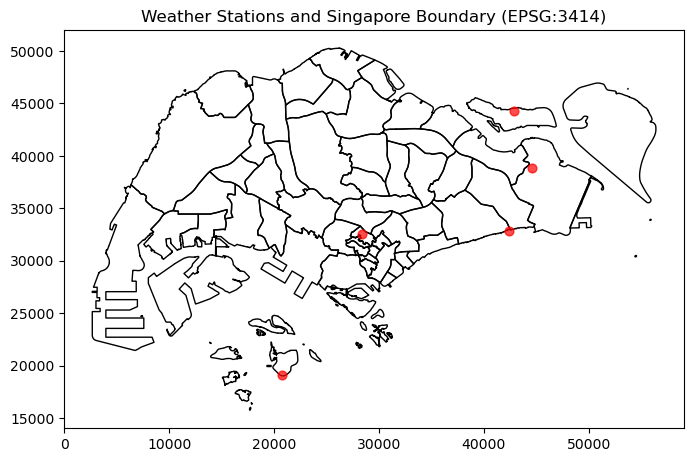

In [ ]:
### Reproject all layers to ESPG:3414 ###
svy21 = arcpy.SpatialReference(3414)

# Reproject temperature and RH points
temp_rh_svy21 = os.path.join(gdb_path, "temp_rh_stations_svy21")
arcpy.management.Project(temp_rh_local, temp_rh_svy21, svy21)
print("Reprojected WeatherStations to EPSG:3414:", os.path.normpath(temp_rh_svy21))

# Reproject boundary shapefile
boundary_svy21 = os.path.join(gdb_path, "boundary_svy21")
arcpy.management.Project(boundary_shp, boundary_svy21, svy21)
print("Reprojected Singapore boundary to EPSG:3414:", os.path.normpath(boundary_svy21))

# Plot layers to check
boundary_shp = os.path.join(local_workspace, "boundary_svy21.shp")
points_shp = os.path.join(local_workspace, "temp_rh_svy21.shp")

arcpy.conversion.FeatureClassToFeatureClass(boundary_svy21, local_workspace, "boundary_svy21.shp")
arcpy.conversion.FeatureClassToFeatureClass(temp_rh_svy21, local_workspace, "temp_rh_svy21.shp")

boundary_gdf = gpd.read_file(boundary_shp)
points_gdf = gpd.read_file(points_shp)

fig, ax = plt.subplots(figsize=(8, 8))
boundary_gdf.plot(ax=ax, color="none", edgecolor="black", linewidth=1)
points_gdf.plot(ax=ax, color="red", markersize=40, alpha=0.7)
ax.set_title("Weather Stations and Singapore Boundary (EPSG:3414)")
plt.show()

In [28]:
### Create raster from boundary shapefile ###
arcpy.env.snapRaster = None
arcpy.env.mask = None
arcpy.env.extent = None

boundary_raster_path = os.path.join(gdb_path, "boundary_rast_30m")
arcpy.conversion.PolygonToRaster(
    in_features=boundary_svy21,
    value_field="OBJECTID",
    out_rasterdataset=boundary_raster_path,
    cell_assignment="MAXIMUM_COMBINED_AREA",
    priority_field="NONE",
    cellsize=30
)
from arcpy.sa import ExtractByMask
boundary_mask = ExtractByMask(boundary_raster_path, boundary_svy21)
boundary_mask.save(boundary_raster_path)

In [30]:
### Interpolate Temperature and RH using IDW ###
arcpy.env.snapRaster = boundary_raster_path
arcpy.env.extent = boundary_svy21
arcpy.env.cellSize = 30
arcpy.env.mask = boundary_svy21
# Define outputs
temp_idw_path = os.path.join(gdb_path, "temp_idw")
rh_idw_path = os.path.join(gdb_path, "rh_idw")

# Interpolate Temperature
temp_idw = Idw(temp_rh_svy21, "temperature", cell_size=30)  # adjust cell size if needed
temp_rast_masked = ExtractByMask(temp_idw, boundary_svy21)
temp_rast_masked.save(temp_idw_path)
print("Created temperature raster at:", temp_idw_path)

# Interpolate RH
rh_idw = Idw(temp_rh_svy21, "rh", cell_size=30)  # adjust cell size if needed
rh_rast_masked = ExtractByMask(rh_idw, boundary_svy21)
rh_rast_masked.save(rh_idw_path)
print("Created RH raster at:", rh_idw_path)

Created temperature raster at: C:/Users/Natalie Woo/Desktop/ge5219_finalProj_workspace\temp_rh.gdb\temp_idw
Created RH raster at: C:/Users/Natalie Woo/Desktop/ge5219_finalProj_workspace\temp_rh.gdb\rh_idw


In [31]:
### Calculate Heat Index Raster ###
from arcpy.sa import Raster, Con, IsNull, ExtractByMask, Float

# Snap raster to the boundary raster
try:
    arcpy.env.snapRaster = boundary_raster_path  # your 30m mask raster
except NameError:
    pass  

arcpy.env.extent   = boundary_svy21
arcpy.env.mask     = boundary_svy21
arcpy.env.cellSize = 30

# Load input rasters
T_C = Raster(temp_idw_path)  # Temperature raster
RH = Raster(rh_idw_path)    # Relative Humidity raster

# Calculate Heat Index using the NOAA Rothfusz regression formula
T_F = (T_C * 9 / 5) + 32  # Convert Celsius to Fahrenheit for use in the formula
HI_F = ( # Apply the formula
    -42.379
    + 2.04901523 * T_F
    + 10.14333127 * RH
    - 0.22475541 * T_F * RH
    - 6.83783e-3 * (T_F ** 2)
    - 5.481717e-2 * (RH ** 2)
    + 1.22874e-3 * (T_F ** 2) * RH
    + 8.5282e-4 * T_F * (RH ** 2)
    - 1.99e-6 * (T_F ** 2) * (RH ** 2)
)
HI_C = (HI_F - 32) * 5 / 9  # Convert back to Celsius

# Save Heat Index raster]
hi_raw_path = os.path.join(gdb_path, "heat_index_raw")
HI_C.save(hi_raw_path)
print("Saved raw Heat Index raster:", os.path.normpath(hi_raw_path))

# Mask and clip Heat Index raster to Singapore boundary
HI_final = ExtractByMask(hi_raw_path, boundary_svy21)
hi_final_path = os.path.join(gdb_path, "heat_index_masked")
HI_final.save(hi_final_path)
print("Saved final masked Heat Index raster:", os.path.normpath(hi_final_path))

Saved raw Heat Index raster: C:\Users\Natalie Woo\Desktop\ge5219_finalProj_workspace\temp_rh.gdb\heat_index_raw
Saved final masked Heat Index raster: C:\Users\Natalie Woo\Desktop\ge5219_finalProj_workspace\temp_rh.gdb\heat_index_masked


In [45]:
### Save Heat Index raster as GeoTIFF ###
from arcgis.gis import GIS
hi_tiff_path = os.path.join(data_folder, "heat_index.tif")
arcpy.management.CopyRaster(
    in_raster=hi_final_path,
    out_rasterdataset=hi_tiff_path,
    format="TIFF",
    nodata_value="",
    transform="NONE",
    pixel_type="32_BIT_FLOAT",
    scale_pixel_value="NONE"
)
print("Exported Heat Index raster as GeoTIFF:", os.path.normpath(hi_tiff_path))

print("📂 File exists:", os.path.exists(hi_tiff_path))
print("📏 File size (MB):", round(os.path.getsize(hi_tiff_path) / 1e6, 2))


### Publish to AGOL ###
for item in agol.content.search("owner:e1553302_gis2025"):
    print(f"{item.title} — {item.type}")
    
hi_item.update(data=hi_tiff_path)
print("Updated hosted heat index raster:", hi_item.title)

Exported Heat Index raster as GeoTIFF: c:\Users\Natalie Woo\OneDrive\_NUS 2025-2026\GE5219\ge5219-1\Data\heat_index.tif
📂 File exists: True
📏 File size (MB): 2.83
WeatherStations — Feature Service
flickrSGLongholiday_NW — Feature Service
heat_index — Image
flickrSGLongholiday_NW — CSV


NameError: name 'hi_item' is not defined

In [ ]:
### Allow HI layer to be overridden ###
existing_items = agol.content.search("Heat_Index owner:e1553302_gis2025", item_type="Image Service")
if existing_items:
    existing_item = existing_items[0]
    existing_item.update(data=hi_tiff_path)
    print("Successfully updated existing hosted raster:", existing_item.title)
else:
    print("No existing raster found; publishing new one.")
    hi_item = agol.content.add(item_properties=item_properties, data=hi_tif_path)
    published_hi = hi_item.publish()
    published_hi.share(everyone=True)

No existing raster found; publishing new one.


NameError: name 'item_properties' is not defined